# Hybrid Absorbing Boundary Condition with Submeshes

This notebook presents a finite-element implementation of a two-dimensional **Hybrid Absorbing Boundary Condition (HABC)** for the two-dimensional acoustic wave equation in Firedrake.

Following the formulation in Liu & Sen (2018, Section 2.2), the full computational domain is written as

$$
\Omega = \Omega_{\mathrm{phys}} \cup \Omega_{\mathrm{ext}}, \qquad
\Omega_{\mathrm{ext}} = \Omega_L \cup \Omega_R \cup \Omega_B.
$$

The figure below illustrates the computational domain, where $\Omega_{\mathrm{phys}}$ is the physical region of interest, and $\Omega_L$, $\Omega_R$, and $\Omega_B$ are the absorbing pads on the left, right, and bottom sides of the domain, respectively. The top boundary is a free surface.


<p align="center">
  <img src="habc.png" alt="HABC computational domain" width="320"/>
</p>



The second-order acoustic field is solved on the whole computational domain $\Omega$, while auxiliary one-way fields are solved on the absorbing pad regions $\Omega_i\subset \Omega_{\mathrm{ext}}$. In the implementation, $\Omega$ is represented by the parent mesh, and each $\Omega_i$ is a Firedrake `Submesh` extracted from the marked region of the parent mesh.

Reference: https://doi.org/10.1088/1742-2140/aadd31

## Acoustic Wave Equation and HABC

### Domain decomposition

Let $\mathcal{I}=\{L,R,B\}$ denote the set of absorbing pad (regions outside the physical domain) indices. The full computational domain is

$$
\Omega = \Omega_{\mathrm{phys}} \cup \Omega_{\mathrm{ext}}, \qquad
\Omega_{\mathrm{ext}} = \bigcup_{i\in\mathcal{I}} \Omega_i.
$$

Here, $\Omega_{\mathrm{phys}}$ is the physical region of interest and $\Omega_{\mathrm{ext}}$ is the absorbing extension. In the code, the parent mesh represents $\Omega$, while each pad domain $\Omega_i$ is built as `Submesh(parent_mesh, parent_mesh_topology_dimension, marker)` from marked boundary-strip cells. The physical region $\Omega_{\mathrm{phys}}$ is therefore the complement of the pad subdomains inside the parent mesh.

For each pad, the interior physical/pad interface is

$$
\Gamma_i = \partial\Omega_{\mathrm{phys}} \cap \partial\Omega_i, \qquad i\in\mathcal{I}.
$$

This is the interface recovered in code by `extract_interface_markers(...)`: the child-submesh exterior markers that are not inherited from the outer boundary of the parent mesh.

In this notebook, the third pad ($i=B$) is associated with the second mesh coordinate, denoted $z$.

### Governing equations

The second-order wave equation is solved on the full computational domain:

$$
\frac{1}{c^2}\,\partial_{tt}u_0 - \Delta u_0 = f \qquad \text{in } \Omega.
$$

On each absorbing pad domain $\Omega_i$ ($i\in\mathcal{I}$), we solve the auxiliary one-way transport problem

$$
\frac{1}{c_i}\,\partial_t u_i + s_i\,\partial_{\alpha_i}u_i = 0 \qquad \text{in } \Omega_i.
$$

with directional operators

$$
(s_i,\alpha_i)=(-1,x)\;\text{for }i=L,\qquad
(+1,x)\;\text{for }i=R,\qquad
(+1,z)\;\text{for }i=B.
$$

Here, $u_0=u_0(x,z,t)$ denotes the pressure on all of $\Omega$, while $u_i=u_i(x,z,t)$ denotes the auxiliary field on pad $\Omega_i$. The coefficient $c=c(x,z)>0$ is the acoustic velocity on the computational domain, and $c_i$ is its restriction/interpolation to the corresponding pad space. The forcing term $f$ is applied only to the second-order field. In the code, this is represented by a mixed-space cofunction whose pad components are zero.

### Variables and parameters

The main symbols used in the formulation are:

- $\Omega$: full computational domain.
- $\Omega_{\mathrm{phys}}$: physical domain of interest.
- $\Omega_{\mathrm{ext}}$: absorbing extension, equal to the union of the pad domains.
- $u_0^{n-1}, u_0^n, u_0^{n+1}$: second-order wavefield at three consecutive time levels on $\Omega$.
- $u_i^n$: auxiliary pad-domain wavefield on $\Omega_i$ at time level $n$.
- $\Delta t$: time-step size.
- $V_0$: finite-element space on the full computational domain $\Omega$.
- $V_i$: finite-element space on the absorbing pad submesh $\Omega_i$.
- $V = V_0\times V_L\times V_R\times V_B$: mixed product space used by the coupled formulation.
- $v=(v_0,v_L,v_R,v_B)\in V$: mixed test function.
- $\langle f^{n+1}, v_0\rangle$: source contribution at time level $n+1$, written as the action of a dual functional on the second-order field test function.
- $\Gamma_i$: interface between the physical domain and the pad $\Omega_i$.
- $u_0^{n+1,+}$: trace of the second-order field taken from the physical side of $\Gamma_i$, matching Firedrake's `u0("+")` notation.
- $w_i\in[0,1]$: HABC blending weight controlling how strongly the pad solution contributes to the reconstructed field.

### Mixed weak form

Let $V = V_0\times V_L\times V_R\times V_B$ be the mixed function space, and let $v=(v_0,v_L,v_R,v_B)\in V$. The volume part of the semi-discrete formulation is

$$
\int_{\Omega}\left[
\frac{1}{c^2}\frac{u_0^{n+1}-2u_0^n+u_0^{n-1}}{\Delta t^2}v_0
+ \nabla u_0^{n+1}\cdot\nabla v_0
\right]dx
+ \sum_{i\in\mathcal{I}}\int_{\Omega_i}\left[
\frac{1}{c_i}\frac{u_i^{n+1}-u_i^n}{\Delta t}v_i
+ s_i\,\partial_{\alpha_i}u_i^{n+1}v_i
\right]dx
= \langle f^{n+1}, v_0\rangle.
$$

The second-order field is therefore solved on the full extended domain $\Omega = \Omega_{\mathrm{phys}}\cup\Omega_{\mathrm{ext}}$, while each pad carries a first-order one-way transport update on its own support.

The interface constraints are imposed separately, via Firedrake `EquationBC` objects on the pad subspaces, through

$$
\int_{\Gamma_i} (u_i^{n+1} - u_0^{n+1,+})\,v_i\,ds = 0, \qquad i\in\mathcal{I}.
$$

### Parent-field reconstruction

After solving the mixed system, we obtain $u_0^{n+1}$ on $\Omega$ and $u_i^{n+1}$ on $\Omega_i$. On each pad region, the second-order solution $u_0^{n+1}$ is updated by

$$
u_0^{n+1} = (1-w_i)\,u_0^{n+1} + w_i\,u_i^{n+1},
\qquad w_i\in[0,1].
$$

In the implementation, this reconstruction is applied sequentially by `apply_weighted_habc_reconstruction(...)` after each call to `solver.solve()`. 

The following code cell defines the computational dependencies and the simulation configuration.

The `SimulationConfig` container collects the main numerical parameters:

- `dt`: time-step size.
- `final_time`: total simulated time.
- `nx`, `ny`: number of parent-mesh subdivisions.
- `domain_length`: side length of the parent square domain.
- `pad_width`: length of each absorbing pad.
- `frequency_peak`: dominant frequency of the Ricker source wavelet.
- `source_locations`: coordinates of the source points used for injection.
- `pad_left_marker`, `pad_right_marker`, `pad_bottom_marker`: integer labels used to identify the left, right, and bottom pad regions in the mesh.

In [9]:
from typing import Any

import firedrake as fd
import finat
import matplotlib.pyplot as plt
import numpy as np


class SimulationConfig:
    """Parameter container for the HABC numerical experiment."""

    dt: float = 0.001
    final_time: float = 1.0
    nx: int = 80
    ny: int = 80
    domain_length: float = 1.5
    pad_width: float = 0.2
    frequency_peak: float = 7.0
    source_locations: tuple[tuple[float, float], ...] = ((0.75, 0.75),)
    pad_left_marker: int = 999
    pad_right_marker: int = 998
    pad_bottom_marker: int = 997

    @property
    def total_steps(self) -> int:
        """Return the number of time-marching steps over the simulation horizon."""
        return int(self.final_time / self.dt) + 1



Following the source-injection strategy as adopted in the Firedrake full-waveform inversion tutorial, the forcing term is represented in separable form:

$$
f_s(\mathbf{x}, t) = r(t)\,q_s(\mathbf{x}), \qquad q_s\in V_0^*.
$$

Here, $r(t)$ is the temporal signature (Ricker wavelet), and $q_s$ is a spatial cofunction in the dual of the parent space.

- `evaluate_ricker_wavelet(...)` defines $r(t)$;
- `assemble_source_cofunction(...)` constructs $q_s$ via `VertexOnlyMesh`, and interpolates it into the dual space $V^{\ast}_0$.

In [10]:
def evaluate_ricker_wavelet(
    time: float,
    peak_frequency: float,
    amplitude: float = 1.0,
) -> float:
    """Evaluate the Ricker source wavelet at time $t$."""
    ts = 1.5
    shifted_time = time - ts * np.sqrt(6.0) / (np.pi * peak_frequency)
    omega = 2.0 * np.pi * peak_frequency
    omega_squared = omega * omega
    factor = 1.0 - 0.5 * omega_squared * shifted_time * shifted_time
    return amplitude * factor * np.exp(
        -0.25 * omega_squared * shifted_time * shifted_time
    )


def assemble_source_cofunction(
    mesh: Any,
    parent_space: fd.FunctionSpace,
    source_location: tuple[float, float],
) -> fd.Cofunction:
    """Embed a point-source density into the dual of the parent space."""
    source_mesh = fd.VertexOnlyMesh(mesh, [source_location])
    source_space = fd.FunctionSpace(source_mesh, "DG", 0)
    source_density = fd.Function(source_space).interpolate(1.0)
    source_cofunction = fd.assemble(
        source_density * fd.TestFunction(source_space) * fd.dx
    )
    return fd.Cofunction(parent_space.dual()).interpolate(source_cofunction)

The next function extracts the internal child-mesh facets that belong to the parent/pad interface.

In [11]:
def extract_interface_markers(
    parent_mesh: Any,
    child_mesh: Any,
) -> tuple[int, ...]:
    """Return child-submesh facet markers not located on the parent exterior.

    The returned set identifies candidate parent/child interface markers
    used in the coupling constraints.
    """
    parent_exterior = {
        int(marker)
        for marker in parent_mesh.exterior_facets.unique_markers
    }
    child_exterior = {
        int(marker)
        for marker in child_mesh.exterior_facets.unique_markers
    }
    return tuple(sorted(child_exterior - parent_exterior))




This section constructs the absorbing pad domains as submeshes of the parent mesh. The helper `build_pad_submeshes(...)` returns the left, right, and bottom pad domains together with an intersected parent measure required to assemble the coupled variational form.

The pads are selected from boundary strips of the parent mesh:

- left pad: $x < \delta$,
- right pad: $L-x < \delta$,
- bottom pad: $L-z < \delta$.

In [12]:
def build_indicator_submesh(
    mesh: Any,
    dq0: fd.FunctionSpace,
    indicator_expr: Any,
    marker: int,
) -> Any:
    """Construct a submesh from a DG indicator-based cell selection."""
    indicator = fd.Function(dq0).interpolate(
        fd.conditional(indicator_expr, 1, 0)
    )
    mesh.mark_entities(indicator, marker)
    return fd.Submesh(mesh, 2, marker)


def build_pad_submeshes(
    mesh: Any,
    pad_width: fd.Constant,
    domain_length: float,
    markers: tuple[int, int, int],
) -> tuple[Any, Any, Any, fd.Measure]:
    """Construct absorbing pad submeshes and an intersected parent-domain measure."""
    pad_left_marker, pad_right_marker, pad_bottom_marker = markers
    x, z = fd.SpatialCoordinate(mesh)
    distance_left = x
    distance_right = domain_length - x
    distance_vertical = domain_length - z

    dq0 = fd.FunctionSpace(mesh, "DG", 0)
    submesh_left = build_indicator_submesh(
        mesh,
        dq0,
        distance_left < pad_width,
        pad_left_marker,
    )
    submesh_right = build_indicator_submesh(
        mesh,
        dq0,
        distance_right < pad_width,
        pad_right_marker,
    )
    submesh_third = build_indicator_submesh(
        mesh,
        dq0,
        fd.And(
            distance_vertical < pad_width,
            fd.And(
                distance_left > pad_width,
                distance_right > pad_width,
            ),
        ),
        pad_bottom_marker,
    )

    dx_parent_intersect = fd.Measure(
        "dx",
        domain=mesh,
        intersect_measures=(
            fd.Measure("dx", submesh_left),
            fd.Measure("dx", submesh_right),
            fd.Measure("dx", submesh_third),
        ),
    )
    return submesh_left, submesh_right, submesh_third, dx_parent_intersect



With $L$ the side length of the parent square and $\delta$ = `transition_width`, the code uses

$$
w_L(x,z)=\max\!\left(0,\,\frac{\delta-x}{\delta}\right), \qquad
w_R(x,z)=\max\!\left(0,\,\frac{\delta-(L-x)}{\delta}\right), \qquad
w_B(x,z)=\max\!\left(0,\,\frac{\delta-(L-z)}{\delta}\right),
$$

on $\Omega_L$, $\Omega_R$, and $\Omega_B$, respectively.

These weights satisfy $w_i=0$ at the inner interface between $\Omega_{\mathrm{phys}}$ and $\Omega_i$, and $w_i=1$ at the outer truncation boundary of the pad.

In [13]:
def build_pad_transition_weights(
    submesh_left: Any,
    submesh_right: Any,
    submesh_third: Any,
    left_space: fd.FunctionSpace,
    right_space: fd.FunctionSpace,
    third_space: fd.FunctionSpace,
    domain_length: float,
    transition_width: fd.Constant,
) -> list[fd.Function]:
    """Construct piecewise-linear transition weights on each absorbing pad domain."""
    x_left, _ = fd.SpatialCoordinate(submesh_left)
    x_right, _ = fd.SpatialCoordinate(submesh_right)
    _, z_third = fd.SpatialCoordinate(submesh_third)

    distance_left = x_left
    distance_right = domain_length - x_right
    distance_vertical = domain_length - z_third

    weight_left_expr = fd.conditional(
        distance_left < transition_width,
        (transition_width - distance_left) / transition_width,
        0.0,
    )
    weight_right_expr = fd.conditional(
        distance_right < transition_width,
        (transition_width - distance_right) / transition_width,
        0.0,
    )
    weight_third_expr = fd.conditional(
        distance_vertical < transition_width,
        (transition_width - distance_vertical) / transition_width,
        0.0,
    )

    return [
        fd.Function(left_space).interpolate(weight_left_expr),
        fd.Function(right_space).interpolate(weight_right_expr),
        fd.Function(third_space).interpolate(weight_third_expr),
    ]



The following cell assembles the coupled mixed variational problem for one time step of the HABC method.

The assembled system contains:
- a second-order finite-difference-in-time update for the parent field on the full mesh;
- first-order one-way transport equations on the three pad domains;
- interface coupling constraints enforced through `EquationBC` on the pad subspaces;
- a `LinearVariationalProblem`/`LinearVariationalSolver` pair and the three time-level states (`u_nm1`, `u_n`, `u_np1`).

This implementation follows the standard Firedrake variational workflow (`TrialFunction`, `TestFunction`, `LinearVariationalProblem`, `LinearVariationalSolver`) while extending it to a mixed parent-plus-pad formulation.

In [14]:
def assemble_wave_step_solver(
    c: fd.Function,
    source_function: fd.Cofunction,
    dt: float,
    mixed_space: fd.FunctionSpace,
    dx_parent_intersect: fd.Measure,
    quad_rule0: Any,
) -> tuple[
    fd.LinearVariationalSolver,
    fd.Function,
    fd.Function,
    fd.Function,
    tuple[fd.Function, ...],
]:
    """Assemble and return the mixed variational solver for one HABC time step."""
    u = fd.TrialFunction(mixed_space)
    v = fd.TestFunction(mixed_space)
    u_components = fd.split(u)
    v_components = fd.split(v)
    u0 = u_components[0]
    v0 = v_components[0]

    u_n = fd.Function(mixed_space)
    u_nm1 = fd.Function(mixed_space)
    u_np1 = fd.Function(mixed_space)
    u_n_components = u_n.subfunctions
    u_nm1_components = u_nm1.subfunctions
    u_n0 = u_n_components[0]
    u_nm10 = u_nm1_components[0]

    pad_subspaces = [mixed_space.sub(1), mixed_space.sub(2), mixed_space.sub(3)]
    parent_mesh = mixed_space.sub(0).mesh()
    pad_meshes = [space.mesh() for space in pad_subspaces]
    c_subspaces = [
        fd.Function(space).interpolate(c, allow_missing_dofs=True)
        for space in pad_subspaces
    ]
    u_n0_subspaces = [
        fd.Function(space).interpolate(u_n0, allow_missing_dofs=True)
        for space in pad_subspaces
    ]

    m = 1 / (c * c)
    dt_const = fd.Constant(dt)
    dt2_const = fd.Constant(dt**2)
    dx_parent_rule = (
        dx_parent_intersect(scheme=quad_rule0)
        if quad_rule0 is not None
        else dx_parent_intersect
    )
    wave_form = (
        m * (u0 - 2.0 * u_n0 + u_nm10) / dt2_const * v0 * dx_parent_rule
        + fd.dot(fd.grad(u0), fd.grad(v0)) * dx_parent_rule
    )

    bcs = []
    direction_data = [(-1.0, 0), (1.0, 0), (1.0, 1)]
    for idx, (
        space,
        pad_mesh,
        c_sub,
        (direction_sign, direction_axis),
    ) in enumerate(
        zip(pad_subspaces, pad_meshes, c_subspaces, direction_data),
        start=1,
    ):
        u_i = u_components[idx]
        v_i = v_components[idx]
        u_n_i = u_n_components[idx]

        dx_i = fd.Measure(
            "dx",
            domain=pad_mesh,
            intersect_measures=(fd.Measure("dx", parent_mesh),),
        )
        ds_i_int = fd.Measure(
            "ds",
            domain=pad_mesh,
            intersect_measures=(fd.Measure("dS", parent_mesh),),
        )

        wave_form += (
            (1 / c_sub) * (u_i - u_n_i) / dt_const * v_i * dx_i
            + direction_sign * u_i.dx(direction_axis) * v_i * dx_i
        )

        interface_markers = extract_interface_markers(parent_mesh, pad_mesh)
        if not interface_markers:
            raise ValueError(
                "No interface markers found between parent mesh and "
                f"submesh_{idx}"
            )

        interface_eq = (
            fd.inner(u_i - u0("+"), v_i) * ds_i_int(interface_markers)
            == fd.inner(fd.Constant(0.0), v_i) * ds_i_int(interface_markers)
        )
        bcs.append(
            fd.EquationBC(interface_eq, u_np1, interface_markers, V=space)
        )

    problem = fd.LinearVariationalProblem(
        fd.lhs(wave_form),
        fd.rhs(wave_form) + source_function,
        u_np1,
        bcs=bcs,
    )
    solver_parameters = {
        "mat_type": "matfree",
        "ksp_type": "gmres",
        "pc_type": "bjacobi",
        "ksp_rtol": 1.0e-8,
    }
    solver = fd.LinearVariationalSolver(
        problem,
        solver_parameters=solver_parameters,
    )
    return solver, u_np1, u_n, u_nm1, tuple(u_n0_subspaces)




After each call to `solver.solve()`, the mixed state `u_np1` stores:
- the parent update $u_0^{n+1}=u_{np1}[0]$;
- the pad updates $u_i^{n+1}=u_{np1}[i]$, $i\in\mathcal{I}=\{L,R,B\}$.

The HABC reconstruction updates $u_0^{n+1}$ through weighted pad contributions. For each pad domain $i$,

$$
u_0^{n+1} \leftarrow (1-w_i)\,u_0^{n+1} + w_i\,u_i^{n+1},
\qquad w_i\in[0,1].
$$

Therefore, $w_i=0$ preserves the parent value on that pad support, $w_i=1$ enforces full pad replacement there, and $0<w_i<1$ defines a linear transition. In the code implementation, this operation is performed by `apply_weighted_habc_reconstruction(...)`, which interpolates weighted pad contributions to the parent space and updates `u_np1.subfunctions[0]` before time-level advancement. The cross-mesh interpolation uses `allow_missing_dofs=True`. Thus, only degrees of freedom lying on the corresponding pad support contribute to each update.

In [15]:
def apply_weighted_habc_reconstruction(
    parent_component: fd.Function,
    pad_components: list[fd.Function],
    pad_weights: list[fd.Function],
    parent_weights: list[fd.Function],
    weighted_pad_sums: list[fd.Function],
) -> None:
    """Apply weighted HABC reconstruction from pad domains to the parent component."""
    for pad_weight, pad_component, weighted_pad_sum, parent_weight in zip(
        pad_weights,
        pad_components,
        weighted_pad_sums,
        parent_weights,
    ):
        weighted_pad_sum.interpolate(
            pad_weight * pad_component,
            allow_missing_dofs=True,
        )
        parent_weight.interpolate(pad_weight, allow_missing_dofs=True)
        parent_component.interpolate(
            (1.0 - parent_weight) * parent_component + weighted_pad_sum
        )



The final cell executes the complete simulation workflow:
- construct the parent mesh, pad submeshes, function spaces, and quadrature;
- assemble the source term and initialize the mixed solver;
- advance the solution in time with wavelet-driven right-hand-side updates;
- apply HABC reconstruction and shift time levels ($u_{nm1} \leftarrow u_n \leftarrow u_{np1}$);
- visualise the final parent-domain pressure field.

/Users/ddolci/dev_code/venv-firedrake/lib/python3.14/site-packages/ufl/utils/sorting.py:94: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/Users/ddolci/dev_code/venv-firedrake/lib/python3.14/site-packages/ufl/utils/sorting.py:94: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(


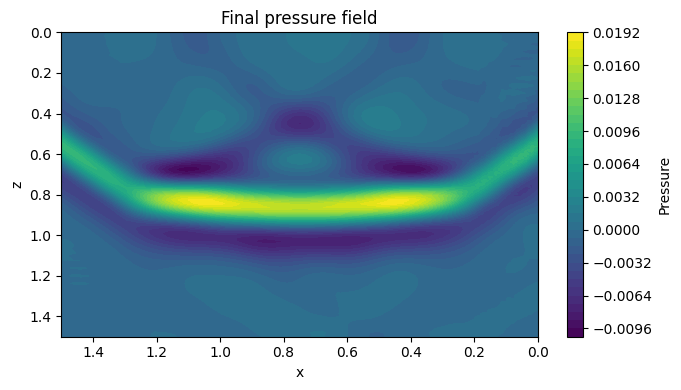

In [8]:
"""Execute the HABC time-marching simulation and visualize the final parent-domain pressure field."""
simulation = SimulationConfig()

source_locations = np.asarray(simulation.source_locations, dtype=float)
source_location = tuple(source_locations[0])

pad_width = fd.Constant(simulation.pad_width)
parent_mesh = fd.SquareMesh(
    simulation.nx,
    simulation.ny,
    simulation.domain_length,
    comm=fd.COMM_WORLD,
)
submesh_left, submesh_right, submesh_third, dx_parent_intersect = build_pad_submeshes(
    parent_mesh,
    pad_width,
    simulation.domain_length,
    (
        simulation.pad_left_marker,
        simulation.pad_right_marker,
        simulation.pad_bottom_marker,
    ),
)

parent_space = fd.FunctionSpace(parent_mesh, "KMV", 1)
left_space = fd.FunctionSpace(submesh_left, "KMV", 1)
right_space = fd.FunctionSpace(submesh_right, "KMV", 1)
third_space = fd.FunctionSpace(submesh_third, "KMV", 1)
mixed_space = parent_space * left_space * right_space * third_space

quad_rule0 = finat.quadrature.make_quadrature(
    parent_space.finat_element.cell,
    parent_space.ufl_element().degree(),
    "KMV",
)
velocity = fd.Function(parent_space).interpolate(2.0)

source_term = assemble_source_cofunction(
    parent_mesh,
    parent_space,
    source_location,
)
rhs_term = fd.Cofunction(mixed_space.dual())
solver, u_np1, u_n, u_nm1, u_n0_subspaces = assemble_wave_step_solver(
    velocity,
    rhs_term,
    simulation.dt,
    mixed_space,
    dx_parent_intersect,
    quad_rule0,
)

u_n0 = u_n.subfunctions[0]
parent_next = u_np1.subfunctions[0]
pad_components = [
    u_np1.subfunctions[1],
    u_np1.subfunctions[2],
    u_np1.subfunctions[3],
]

pad_weights = build_pad_transition_weights(
    submesh_left,
    submesh_right,
    submesh_third,
    left_space,
    right_space,
    third_space,
    simulation.domain_length,
    pad_width,
)
parent_weights = [fd.Function(parent_space) for _ in pad_weights]
weighted_pad_sums = [fd.Function(parent_space) for _ in pad_weights]

for step in range(simulation.total_steps):
    time = step * simulation.dt
    source_value = evaluate_ricker_wavelet(time, simulation.frequency_peak)
    rhs_term.sub(0).assign(source_value * source_term)

    for u_n0_sub in u_n0_subspaces:
        u_n0_sub.interpolate(u_n0, allow_missing_dofs=True)

    solver.solve()
    apply_weighted_habc_reconstruction(
        parent_component=parent_next,
        pad_components=pad_components,
        pad_weights=pad_weights,
        parent_weights=parent_weights,
        weighted_pad_sums=weighted_pad_sums,
    )

    u_nm1.assign(u_n)
    u_n.assign(u_np1)

# Visualize the final parent-domain pressure field
fig, ax = plt.subplots(figsize=(7, 4))
contour = fd.tricontourf(parent_next, axes=ax, levels=40, cmap="viridis")
fig.colorbar(contour, ax=ax, label="Pressure")
ax.set_title("Final pressure field")
ax.set_xlabel("x")
ax.set_ylabel("z")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()
